In [1]:
pip install numpy pandas scikit-learn tensorflow matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

data = pd.read_excel("dataset.xlsx")

data.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


In [5]:
print(data.columns)

Index(['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH',
       'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours',
       'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml',
       'sowing_date', 'harvest_date', 'total_days', 'yield_kg_per_hectare',
       'sensor_id', 'timestamp', 'latitude', 'longitude', 'NDVI_index',
       'crop_disease_status'],
      dtype='object')


In [6]:
data = data[['soil_moisture_%','temperature_C','humidity_%','NDVI_index','crop_disease_status']]

data.head()

,soil_moisture_%,temperature_C,humidity_%,NDVI_index,crop_disease_status
0,35.95,17.79,77.03,0.63,Mild
1,19.74,30.18,61.13,0.58,NaN
2,29.32,27.37,68.87,0.80,Mild
3,17.33,33.73,70.46,0.44,NaN
4,19.37,33.86,55.73,0.84,Severe


In [7]:
data['crop_disease_status'] = data['crop_disease_status'].fillna("Healthy")

data['stress'] = data['crop_disease_status'].apply(
    lambda x: 0 if x == "Healthy" else 1
)

data.head()


,soil_moisture_%,temperature_C,humidity_%,NDVI_index,crop_disease_status,stress
0,35.95,17.79,77.03,0.63,Mild,1
1,19.74,30.18,61.13,0.58,Healthy,0
2,29.32,27.37,68.87,0.80,Mild,1
3,17.33,33.73,70.46,0.44,Healthy,0
4,19.37,33.86,55.73,0.84,Severe,1


In [8]:
data = data.drop(columns=['crop_disease_status'])

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(data[['soil_moisture_%','temperature_C','humidity_%','NDVI_index']])
y = data['stress']

In [10]:
import numpy as np

sequence_length = 10

X_seq = []
y_seq = []

for i in range(len(X) - sequence_length):
    X_seq.append(X[i:i+sequence_length])
    y_seq.append(y.iloc[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model = Sequential()

model.add(GRU(32, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,193 (16.38 KB)

 Trainable params: 4,193 (16.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6326 - loss: 0.6798 - val_accuracy: 0.7089 - val_loss: 0.6589
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7412 - loss: 0.6365 - val_accuracy: 0.7089 - val_loss: 0.6293
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7412 - loss: 0.6021 - val_accuracy: 0.7089 - val_loss: 0.6107
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7412 - loss: 0.5796 - val_accuracy: 0.7089 - val_loss: 0.6063
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7412 - loss: 0.5730 - val_accuracy: 0.7089 - val_loss: 0.6119
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7412 - loss: 0.5756 - val_accuracy: 0.7089 - val_loss: 0.6110
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7412 - loss: 0.5752 - val_accuracy: 0.7089 - val_loss: 0.6090
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7412 - loss: 0.5739 - val_accuracy: 0.7089 - v

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step 
Accuracy: 0.7755102040816326
Precision: 0.7755102040816326
Recall: 1.0
F1 Score: 0.8735632183908046


In [15]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


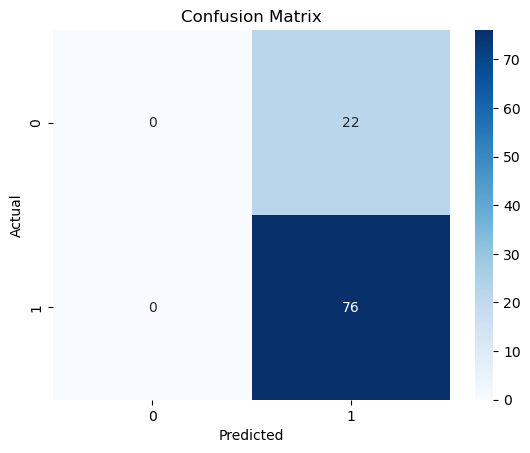

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

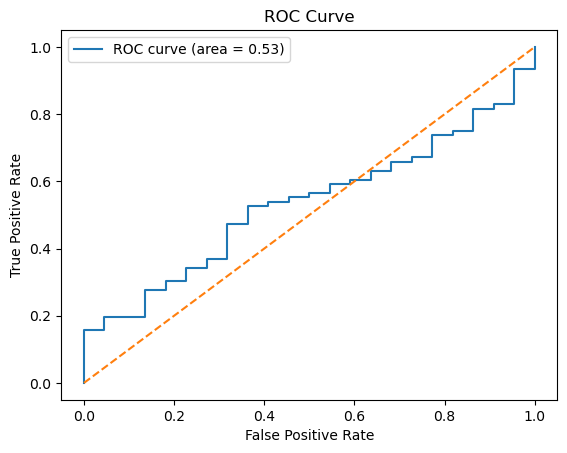

In [17]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.78      1.00      0.87        76

    accuracy                           0.78        98
   macro avg       0.39      0.50      0.44        98
weighted avg       0.60      0.78      0.68        98



C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# GRU MODEL METRICS
# -----------------------------

y_pred_gru_prob = model.predict(X_test)
y_pred_gru = (y_pred_gru_prob > 0.5).astype(int)

accuracy_gru = accuracy_score(y_test, y_pred_gru)
precision_gru = precision_score(y_test, y_pred_gru)
recall_gru = recall_score(y_test, y_pred_gru)
f1_gru = f1_score(y_test, y_pred_gru)

# -----------------------------
# RANDOM FOREST MODEL
# -----------------------------

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_ml, y_train_ml)

y_pred_rf = rf.predict(X_test_ml)
y_prob_rf = rf.predict_proba(X_test_ml)[:,1]

accuracy_rf = accuracy_score(y_test_ml, y_pred_rf)
precision_rf = precision_score(y_test_ml, y_pred_rf)
recall_rf = recall_score(y_test_ml, y_pred_rf)
f1_rf = f1_score(y_test_ml, y_pred_rf)

# -----------------------------
# COMPARISON TABLE
# -----------------------------

comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "GRU"],
    "Accuracy": [accuracy_rf, accuracy_gru],
    "Precision": [precision_rf, precision_gru],
    "Recall": [recall_rf, recall_gru],
    "F1 Score": [f1_rf, f1_gru]
})

print(comparison_table)

# -----------------------------
# CONFUSION MATRIX (GRU)
# -----------------------------

cm = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - GRU")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# ROC CURVE COMPARISON
# -----------------------------

fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_gru_prob)
roc_auc_gru = auc(fpr_gru, tpr_gru)

fpr_rf, tpr_rf, _ = roc_curve(y_test_ml, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_gru, tpr_gru, label=f"GRU (AUC = {roc_auc_gru:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step 


NameError: name 'X_train_ml' is not defined

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest   0.67000   0.711111  0.901408  0.795031
1            GRU   0.77551   0.775510  1.000000  0.873563


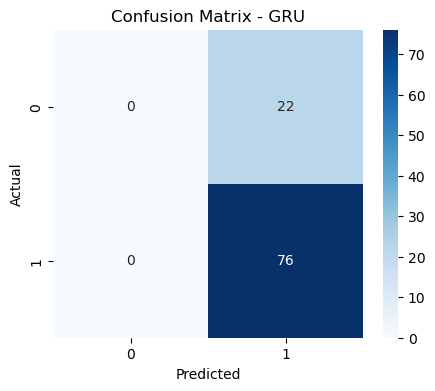

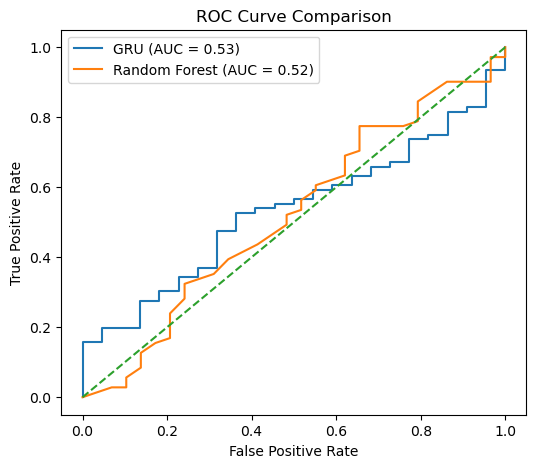

In [20]:
from sklearn.model_selection import train_test_split

# features
X_ml = data[['soil_moisture_%','temperature_C','humidity_%','NDVI_index']]

# target
y_ml = data['stress']

# split dataset
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# GRU MODEL METRICS
# -----------------------------

y_pred_gru_prob = model.predict(X_test)
y_pred_gru = (y_pred_gru_prob > 0.5).astype(int)

accuracy_gru = accuracy_score(y_test, y_pred_gru)
precision_gru = precision_score(y_test, y_pred_gru)
recall_gru = recall_score(y_test, y_pred_gru)
f1_gru = f1_score(y_test, y_pred_gru)

# -----------------------------
# RANDOM FOREST MODEL
# -----------------------------

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_ml, y_train_ml)

y_pred_rf = rf.predict(X_test_ml)
y_prob_rf = rf.predict_proba(X_test_ml)[:,1]

accuracy_rf = accuracy_score(y_test_ml, y_pred_rf)
precision_rf = precision_score(y_test_ml, y_pred_rf)
recall_rf = recall_score(y_test_ml, y_pred_rf)
f1_rf = f1_score(y_test_ml, y_pred_rf)

# -----------------------------
# COMPARISON TABLE
# -----------------------------

comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "GRU"],
    "Accuracy": [accuracy_rf, accuracy_gru],
    "Precision": [precision_rf, precision_gru],
    "Recall": [recall_rf, recall_gru],
    "F1 Score": [f1_rf, f1_gru]
})

print(comparison_table)

# -----------------------------
# CONFUSION MATRIX (GRU)
# -----------------------------

cm = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - GRU")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# ROC CURVE COMPARISON
# -----------------------------

fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_gru_prob)
roc_auc_gru = auc(fpr_gru, tpr_gru)

fpr_rf, tpr_rf, _ = roc_curve(y_test_ml, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_gru, tpr_gru, label=f"GRU (AUC = {roc_auc_gru:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


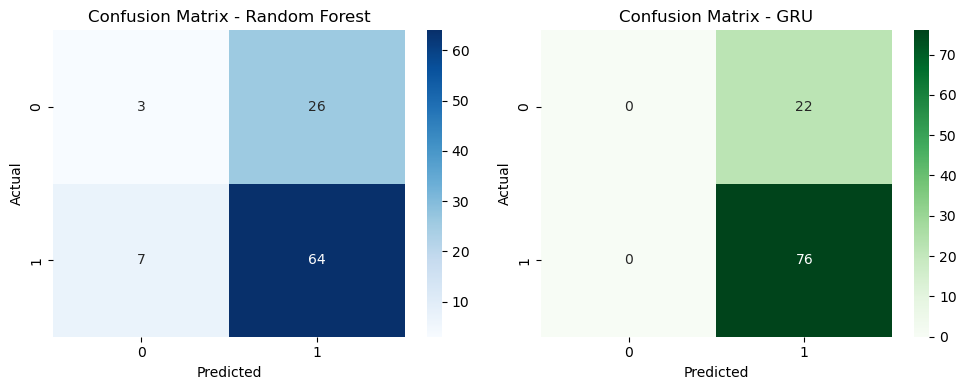

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# GRU predictions
y_pred_gru_prob = model.predict(X_test)
y_pred_gru = (y_pred_gru_prob > 0.5).astype(int)

# Random Forest predictions
y_pred_rf = rf.predict(X_test_ml)

# Confusion matrices
cm_gru = confusion_matrix(y_test, y_pred_gru)
cm_rf = confusion_matrix(y_test_ml, y_pred_rf)

# Plot side-by-side
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - GRU")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

# -----------------------------
# GRU BEFORE TUNING
# -----------------------------

y_pred_gru_prob = model.predict(X_test)
y_pred_gru = (y_pred_gru_prob > 0.5).astype(int)

accuracy_gru = accuracy_score(y_test, y_pred_gru)
precision_gru = precision_score(y_test, y_pred_gru)
recall_gru = recall_score(y_test, y_pred_gru)
f1_gru = f1_score(y_test, y_pred_gru)

# -----------------------------
# GRU AFTER TUNING
# -----------------------------

y_pred_tuned_prob = tuned_model.predict(X_test)
y_pred_tuned = (y_pred_tuned_prob > 0.5).astype(int)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

# -----------------------------
# RANDOM FOREST
# -----------------------------

y_pred_rf = rf.predict(X_test_ml)
y_prob_rf = rf.predict_proba(X_test_ml)[:,1]

accuracy_rf = accuracy_score(y_test_ml, y_pred_rf)
precision_rf = precision_score(y_test_ml, y_pred_rf)
recall_rf = recall_score(y_test_ml, y_pred_rf)
f1_rf = f1_score(y_test_ml, y_pred_rf)

# -----------------------------
# COMPARISON TABLE
# -----------------------------

comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "GRU", "GRU Tuned"],
    "Accuracy": [accuracy_rf, accuracy_gru, accuracy_tuned],
    "Precision": [precision_rf, precision_gru, precision_tuned],
    "Recall": [recall_rf, recall_gru, recall_tuned],
    "F1 Score": [f1_rf, f1_gru, f1_tuned]
})

print(comparison_table)

# -----------------------------
# CONFUSION MATRICES
# -----------------------------

cm_rf = confusion_matrix(y_test_ml, y_pred_rf)
cm_gru = confusion_matrix(y_test, y_pred_gru)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest")

plt.subplot(1,3,2)
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Greens')
plt.title("GRU")

plt.subplot(1,3,3)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges')
plt.title("GRU Tuned")

plt.show()

# -----------------------------
# ROC CURVE COMPARISON
# -----------------------------

fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_gru_prob)
roc_auc_gru = auc(fpr_gru, tpr_gru)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_tuned_prob)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

fpr_rf, tpr_rf, _ = roc_curve(y_test_ml, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")
plt.plot(fpr_gru, tpr_gru, label=f"GRU (AUC={roc_auc_gru:.2f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"GRU Tuned (AUC={roc_auc_tuned:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


NameError: name 'tuned_model' is not defined

In [23]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam


# ==============================
# LOAD DATASET
# ==============================

data = pd.read_excel("dataset.xlsx")

# select important features
features = ['soil_moisture_%','temperature_C','humidity_%','NDVI_index']
target = 'stress'

X = data[features]
y = data[target]


# ==============================
# NORMALIZE FEATURES
# ==============================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# ==============================
# SPLIT DATA
# ==============================

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# ==============================
# RANDOM FOREST MODEL
# ==============================

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_ml, y_train_ml)

y_pred_rf = rf.predict(X_test_ml)
y_prob_rf = rf.predict_proba(X_test_ml)[:,1]


# ==============================
# PREPARE DATA FOR GRU
# ==============================

X_seq = X_scaled.reshape((X_scaled.shape[0],1,X_scaled.shape[1]))

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42
)


# ==============================
# GRU MODEL (BEFORE TUNING)
# ==============================

model = Sequential()

model.add(GRU(32, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

y_pred_gru_prob = model.predict(X_test)
y_pred_gru = (y_pred_gru_prob > 0.5).astype(int)


# ==============================
# TUNED GRU MODEL
# ==============================

tuned_model = Sequential()

tuned_model.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])))
tuned_model.add(Dense(32, activation='relu'))
tuned_model.add(Dense(1, activation='sigmoid'))

tuned_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tuned_model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.2)

y_pred_tuned_prob = tuned_model.predict(X_test)
y_pred_tuned = (y_pred_tuned_prob > 0.5).astype(int)


# ==============================
# METRICS
# ==============================

accuracy_rf = accuracy_score(y_test_ml, y_pred_rf)
precision_rf = precision_score(y_test_ml, y_pred_rf)
recall_rf = recall_score(y_test_ml, y_pred_rf)
f1_rf = f1_score(y_test_ml, y_pred_rf)

accuracy_gru = accuracy_score(y_test, y_pred_gru)
precision_gru = precision_score(y_test, y_pred_gru)
recall_gru = recall_score(y_test, y_pred_gru)
f1_gru = f1_score(y_test, y_pred_gru)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)


# ==============================
# COMPARISON TABLE
# ==============================

comparison = pd.DataFrame({
    "Model":["Random Forest","GRU","GRU Tuned"],
    "Accuracy":[accuracy_rf,accuracy_gru,accuracy_tuned],
    "Precision":[precision_rf,precision_gru,precision_tuned],
    "Recall":[recall_rf,recall_gru,recall_tuned],
    "F1 Score":[f1_rf,f1_gru,f1_tuned]
})

print(comparison)


# ==============================
# CONFUSION MATRICES
# ==============================

cm_rf = confusion_matrix(y_test_ml,y_pred_rf)
cm_gru = confusion_matrix(y_test,y_pred_gru)
cm_tuned = confusion_matrix(y_test,y_pred_tuned)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Blues')
plt.title("Random Forest")

plt.subplot(1,3,2)
sns.heatmap(cm_gru,annot=True,fmt='d',cmap='Greens')
plt.title("GRU")

plt.subplot(1,3,3)
sns.heatmap(cm_tuned,annot=True,fmt='d',cmap='Oranges')
plt.title("GRU Tuned")

plt.show()


# ==============================
# ROC CURVE COMPARISON
# ==============================

fpr_rf,tpr_rf,_=roc_curve(y_test_ml,y_prob_rf)
roc_auc_rf=auc(fpr_rf,tpr_rf)

fpr_gru,tpr_gru,_=roc_curve(y_test,y_pred_gru_prob)
roc_auc_gru=auc(fpr_gru,tpr_gru)

fpr_tuned,tpr_tuned,_=roc_curve(y_test,y_pred_tuned_prob)
roc_auc_tuned=auc(fpr_tuned,tpr_tuned)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf,tpr_rf,label=f"Random Forest (AUC={roc_auc_rf:.2f})")
plt.plot(fpr_gru,tpr_gru,label=f"GRU (AUC={roc_auc_gru:.2f})")
plt.plot(fpr_tuned,tpr_tuned,label=f"GRU Tuned (AUC={roc_auc_tuned:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

KeyError: 'stress'

In [24]:
import time

# GRU inference time
start = time.time()
model.predict(X_test)
gru_time = time.time() - start

# RF inference time
start = time.time()
rf.predict(X_test_ml)
rf_time = time.time() - start

print("GRU Inference Time:", gru_time)
print("RF Inference Time:", rf_time)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
GRU Inference Time: 0.33815956115722656
RF Inference Time: 0.0419614315032959


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

gru_units = [32, 64]
batch_sizes = [16, 32]
epochs_list = [20, 30]

for units in gru_units:
    for batch in batch_sizes:
        for ep in epochs_list:

            model = Sequential()

            model.add(GRU(units, input_shape=(X_train.shape[1], X_train.shape[2])))
            model.add(Dense(16, activation='relu'))
            model.add(Dense(1, activation='sigmoid'))

            model.compile(
                optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )

            model.fit(
                X_train,
                y_train,
                epochs=ep,
                batch_size=batch,
                validation_split=0.2,
                verbose=0
            )

            y_pred = (model.predict(X_test) > 0.5).astype(int)
            acc = accuracy_score(y_test, y_pred)

            results.append({
                "GRU Units": units,
                "Batch Size": batch,
                "Epochs": ep,
                "Accuracy": acc
            })

tuning_results = pd.DataFrame(results)

print(tuning_results)

C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step 


C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step


C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step


C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step 


C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step 
   GRU Units  Batch Size  Epochs  Accuracy
0         32          16      20   0.77551
1         32          16      30   0.77551
2         32          32      20   0.77551
3         32          32      30   0.77551
4         64          16      20   0.77551
5         64          16      30   0.77551
6         64          32      20   0.77551
7         64          32      30   0.77551


In [26]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

In [27]:
# Tuned GRU Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tuned_model = Sequential()

tuned_model.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])))
tuned_model.add(Dense(32, activation='relu'))
tuned_model.add(Dense(1, activation='sigmoid'))

tuned_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# changed batch size and epochs
tuned_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

# predictions
y_pred_tuned = (tuned_model.predict(X_test) > 0.5).astype(int)

# metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Accuracy:", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1 Score:", f1_tuned)

Epoch 1/30


C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.7380 - loss: 0.6229 - val_accuracy: 0.7089 - val_loss: 0.6060
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7412 - loss: 0.5755 - val_accuracy: 0.7089 - val_loss: 0.6128
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7412 - loss: 0.5756 - val_accuracy: 0.7089 - val_loss: 0.6070
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7412 - loss: 0.5780 - val_accuracy: 0.7089 - val_loss: 0.6068
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7412 - loss: 0.5790 - val_accuracy: 0.7089 - val_loss: 0.6061
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7412 - loss: 0.5761 - val_accuracy: 0.7089 - val_loss: 0.6067
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7412 - loss: 0.5748 - val_accuracy: 0.7089 - val_loss: 0.6119
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7412 - loss: 0.5793 - val_accuracy: 0.7089 - val_loss: 0.

In [28]:
import time

start = time.time()
tuned_model.predict(X_test)
tuned_inference = time.time() - start

print("Inference Time:", tuned_inference)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Inference Time: 0.11609673500061035


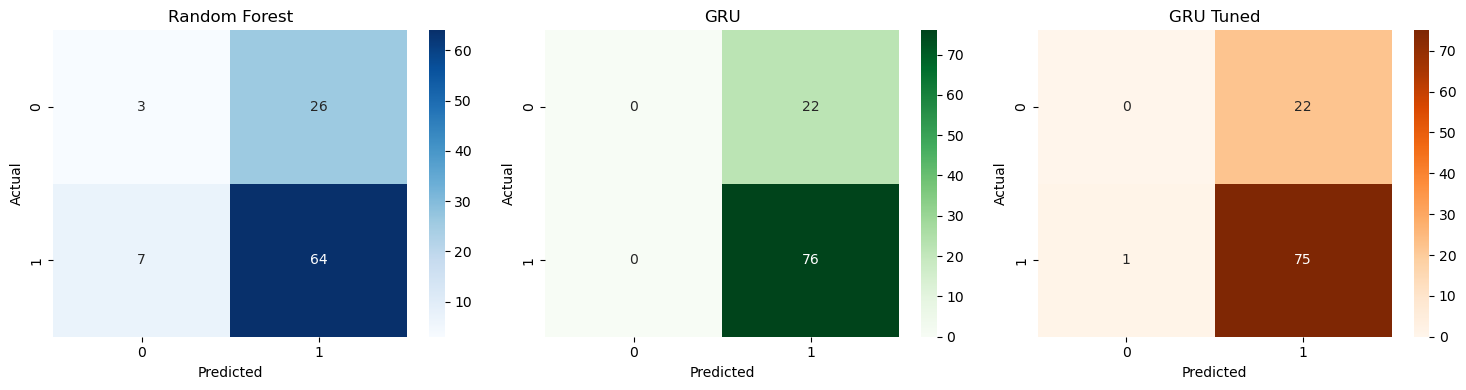

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# confusion matrices
cm_rf = confusion_matrix(y_test_ml, y_pred_rf)
cm_gru = confusion_matrix(y_test, y_pred_gru)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# plot
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,3,2)
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Greens')
plt.title("GRU")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,3,3)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges')
plt.title("GRU Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_ml, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# ROC for GRU
fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_gru_prob)
roc_auc_gru = auc(fpr_gru, tpr_gru)

# ROC for Tuned GRU
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_tuned_prob)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_gru, tpr_gru, label=f"GRU (AUC = {roc_auc_gru:.2f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"GRU Tuned (AUC = {roc_auc_tuned:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

NameError: name 'y_pred_tuned_prob' is not defined

In [31]:
# probability predictions for tuned GRU
y_pred_tuned_prob = tuned_model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


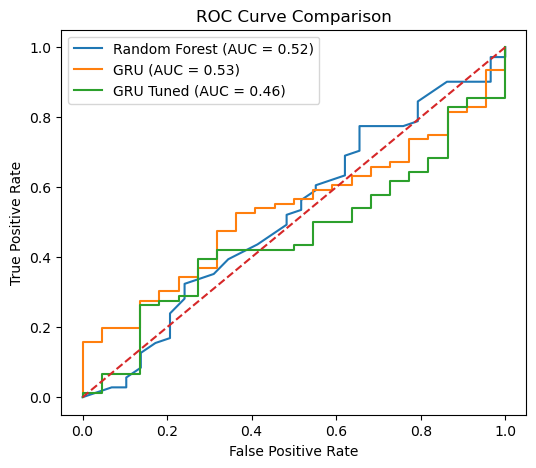

In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_ml, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# ROC for GRU
fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_gru_prob)
roc_auc_gru = auc(fpr_gru, tpr_gru)

# ROC for Tuned GRU
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_tuned_prob)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_gru, tpr_gru, label=f"GRU (AUC = {roc_auc_gru:.2f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"GRU Tuned (AUC = {roc_auc_tuned:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()